In [22]:
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
import pandas as pd
import seaborn as sns
from mne.stats import permutation_cluster_test
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Stier
bdf_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf"
csv_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/data_p9876_20260508_1018.csv"

# Indlæsning af data
raw = mne.io.read_raw_bdf(bdf_path, preload=True)   # .bdf
raw.resample(256)
raw = raw.notch_filter(50)
raw.set_eeg_reference('average', projection=False)
df = pd.read_csv(csv_path)                          # .csv

Extracting BDF parameters from C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf...


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6557695  =      0.000 ...  3202.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

In [3]:
# ICA (Independent Component Analysis) For at fjerne øjenblink
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_ica, decim=3)

# Bed MNE om automatisk at finde blink vha. de forreste elektroder.
eog_channels = ['Fp1', 'Fp2', 'Fpz']
try:
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
    print(f"ICA fandt blink i komponent(er): {eog_indices}")
    ica.exclude = eog_indices
except Exception as e:
    print(f"Kunne ikke finde EOG automatisk (tjek elektrodenavne). Kør ica.plot_components(raw) for at vælge manuelt.")

# Filtrer den RIGTIGE data til ERP-brug (0.1 - 30 Hz) og træk blink-komponenterne ud
raw_clean = raw.copy().filter(l_freq=0.1, h_freq=40.0)
ica.apply(raw_clean)

# Find triggers
events = mne.find_events(raw_clean, stim_channel='Status')

# Sikkerhedstjek: Antal triggers fra EEG skal matche antal trials i CSV
if len(events) > len(df):
    print("Fandt ekstra start/stop triggers i EEG'et. Fjerner dem for at matche CSV...")
    events = events[-len(df):]

tmin, tmax = -0.2, 0.8
reject_criteria = dict(eeg=150e-6)

epochs = mne.Epochs(
    raw_clean,
    events,
    metadata = df,
    #event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=(tmin, 0), # Nulstil baseline (-0.2 til 0) så alle starter samme sted
    preload=True,
    reject=reject_criteria
)

# Hvilke epochs der er droppet efter ICA
print(epochs.drop_log_stats())


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 10.5s.
Using EOG channels: Fp1, Fp2, Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- L

In [4]:
blocks_to_exclude = [1,2,3,4,5,6] #,7,11,15,19,23,27
epochs_main = epochs[f"block_num not in {blocks_to_exclude}"]
epochs_correct = epochs_main["correct == True"]
print(f"Beholder {len(epochs_correct)} trials til selve ERP analysen.")

Beholder 1115 trials til selve ERP analysen.



Beregner ERP'er og statistisk signifikans for alle afvigertyper...

Genererer plots for Auditory Deviant (Sound)...
Using a threshold of 3.851034
stat_fun(H1): min=4.662263386424647e-06 max=11.320951147553593
Running initial clustering …
Found 10 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:03<00:00,  300.74it/s]


Using a threshold of 3.851044
stat_fun(H1): min=0.00020611527864300606 max=21.432096683198065
Running initial clustering …
Found 4 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  334.56it/s]


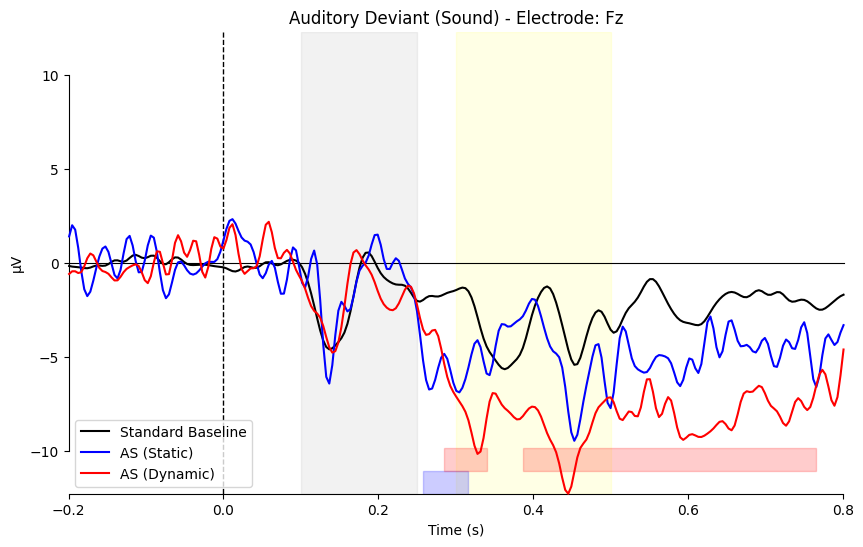

Using a threshold of 3.851034
stat_fun(H1): min=0.00014992115841002464 max=9.905763288914688
Running initial clustering …
Found 5 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  370.06it/s]


Using a threshold of 3.851044
stat_fun(H1): min=4.732739209252678e-05 max=13.516580445168405
Running initial clustering …
Found 4 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  373.85it/s]


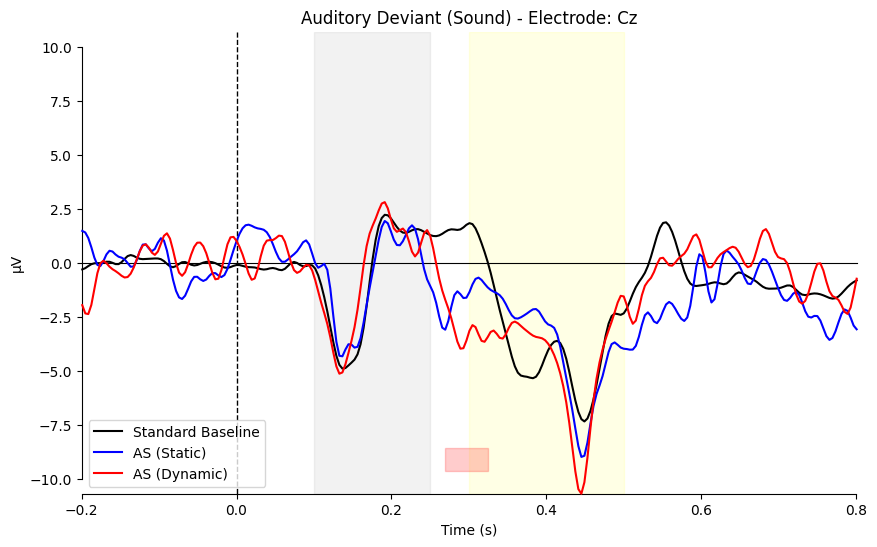


Genererer plots for Visual Deviant (Sight)...
Using a threshold of 3.851113
stat_fun(H1): min=1.8349355434774505e-05 max=12.54104155062203
Running initial clustering …
Found 9 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  363.42it/s]

Using a threshold of 3.851063
stat_fun(H1): min=4.912463794929329e-06 max=87.58944775187348
Running initial clustering …
Found 6 clusters



C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  373.69it/s]


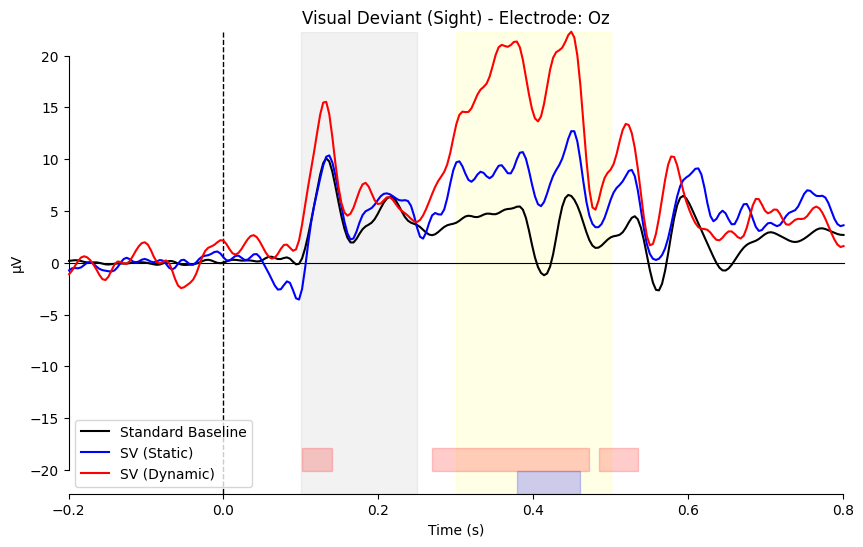

Using a threshold of 3.851113
stat_fun(H1): min=2.8482855204272617e-07 max=9.963052737366539
Running initial clustering …
Found 11 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  358.78it/s]

Using a threshold of 3.851063
stat_fun(H1): min=0.022896295020974042 max=55.752896452370955
Running initial clustering …
Found 4 clusters



C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:03<00:00,  305.42it/s]


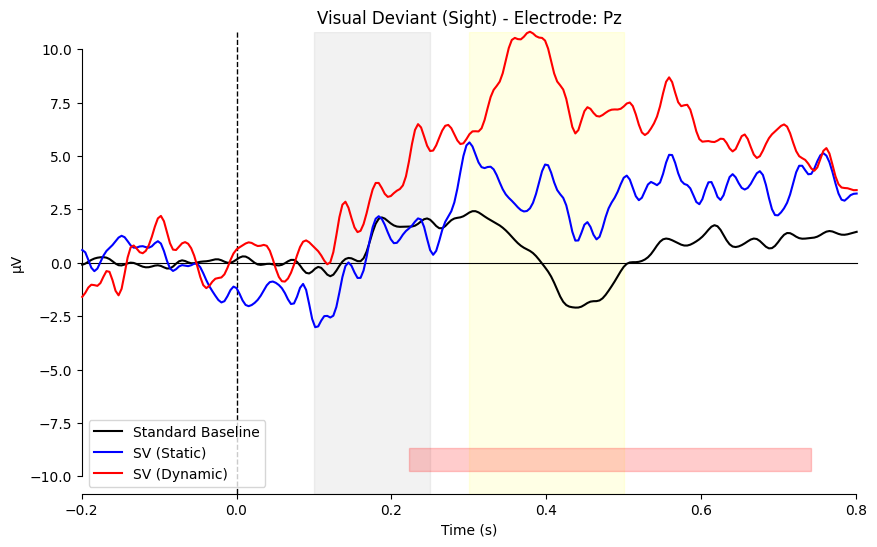


Genererer plots for Multimodal Deviant (Sound+Sight)...
Using a threshold of 3.850975
stat_fun(H1): min=1.6622157433989464e-06 max=10.859207819917517
Running initial clustering …
Found 3 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:03<00:00,  329.85it/s]


Using a threshold of 3.851073
stat_fun(H1): min=5.2926022337248e-06 max=7.302824247800433
Running initial clustering …
Found 6 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  377.65it/s]


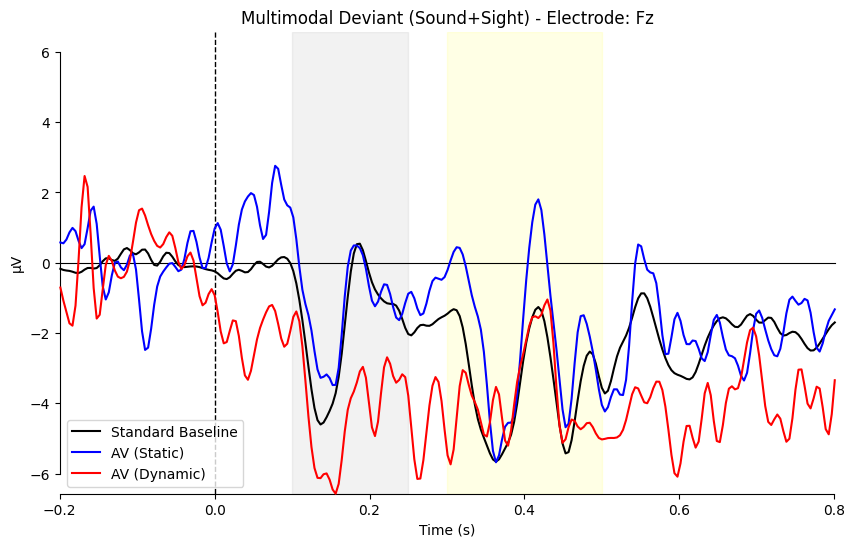

Using a threshold of 3.850975
stat_fun(H1): min=5.047063894223776e-05 max=4.117288756791754
Running initial clustering …
Found 2 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  389.21it/s]


Using a threshold of 3.851073
stat_fun(H1): min=0.00011767972463213481 max=7.766292801857664
Running initial clustering …
Found 5 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  360.70it/s]


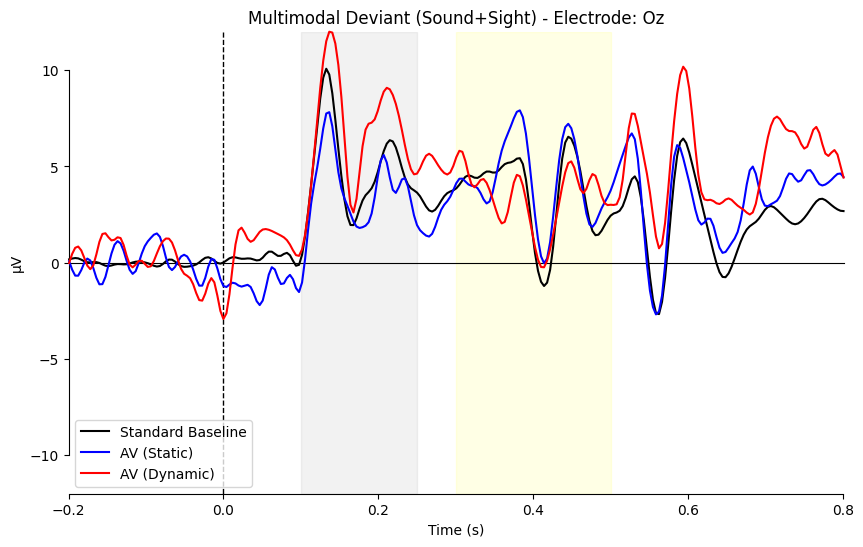

Using a threshold of 3.850975
stat_fun(H1): min=4.265991294798411e-06 max=9.372846387033913
Running initial clustering …
Found 3 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:77: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  379.76it/s]


Using a threshold of 3.851073
stat_fun(H1): min=6.0929824535804704e-05 max=12.618164773203738
Running initial clustering …
Found 5 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\526065022.py:86: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  419.29it/s]


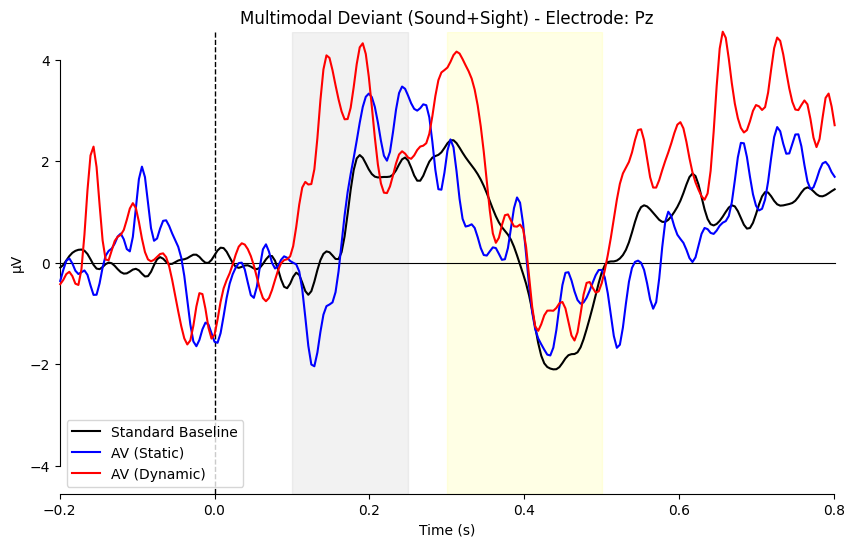

In [6]:
# ==========================================
# 7. ERP PLOTS MED INDBYGGET SIGNIFIKANS
# ==========================================
print("\nBeregner ERP'er og statistisk signifikans for alle afvigertyper...")

cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

deviant_configs = {
    'AS': {
        'name': 'Auditory Deviant (Sound)',
        'channels': ['Fz', 'Cz']
    },
    'SV': {
        'name': 'Visual Deviant (Sight)',
        'channels': ['Oz', 'Pz']
    },
    'AV': {
        'name': 'Multimodal Deviant (Sound+Sight)',
        'channels': ['Fz', 'Oz', 'Pz']
    }
}

for dev_type, config in deviant_configs.items():
    print(f"\nGenererer plots for {config['name']}...")

    # Hent selve epoch-dataen (til at regne signifikans)
    epochs_static = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_std = epochs_correct["stimulus_state == 'standard'"]

    # Hent gennemsnittet (til selve linje-plottet)
    cond_static = epochs_static.average()
    cond_dynamic = epochs_dyn.average()

    evokeds_dict = {
        'Standard Baseline': cond_standard,
        f'{dev_type} (Static)': cond_static,
        f'{dev_type} (Dynamic)': cond_dynamic
    }

    colors = {
        'Standard Baseline': 'black',
        f'{dev_type} (Static)': 'blue',
        f'{dev_type} (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            # --- 1. TEGN SELVE LINJERNE ---
            mne.viz.plot_compare_evokeds(
                evokeds_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} - Electrode: {ch}",
                show_sensors=False,
                show=False # Vent med at vise plottet!
            )

            # --- 2. TEGN MMN/P300 ZONERNE I BAGGRUNDEN ---
            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, zorder=0)

            # --- 3. BEREGN OG TEGN SIGNIFIKANS ---
            ch_idx = epochs_correct.ch_names.index(ch)
            times = epochs_correct.times

            # Data arrays til klyngetesten (squeeze fjerner unødige dimensioner)
            data_std = epochs_std.get_data(picks=ch_idx).squeeze()
            data_stat = epochs_static.get_data(picks=ch_idx).squeeze()
            data_dyn = epochs_dyn.get_data(picks=ch_idx).squeeze()

            # Test: Er STATISK signifikant forskellig fra Standard?
            _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
            if clusters_stat: # Tjek om den overhovedet fandt nogle clusters
                for i_c, c in enumerate(clusters_stat):
                    if p_val_stat[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='blue', alpha=0.2, ymin=0.0, ymax=0.05)

            # Test: Er DYNAMISK signifikant forskellig fra Standard?
            _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
            if clusters_dyn: # Tjek om den overhovedet fandt nogle clusters
                for i_c, c in enumerate(clusters_dyn):
                    if p_val_dyn[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='red', alpha=0.2, ymin=0.05, ymax=0.1)

            # Opdater legend og vis grafen
            # For at undgå at signifikans-boksene står 5 gange i boksen, fjerner vi dubletter
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner antal faktiske afvigere i dataen for alle betingelser...

--- FAKTISK ANTAL DEVIANTS I DATAEN ---
block_type deviant_type  Antal
   Dynamic           AS     29
   Dynamic           AV     26
   Dynamic           SV     27
    Static           AS     30
    Static           AV     36
    Static           SV     22


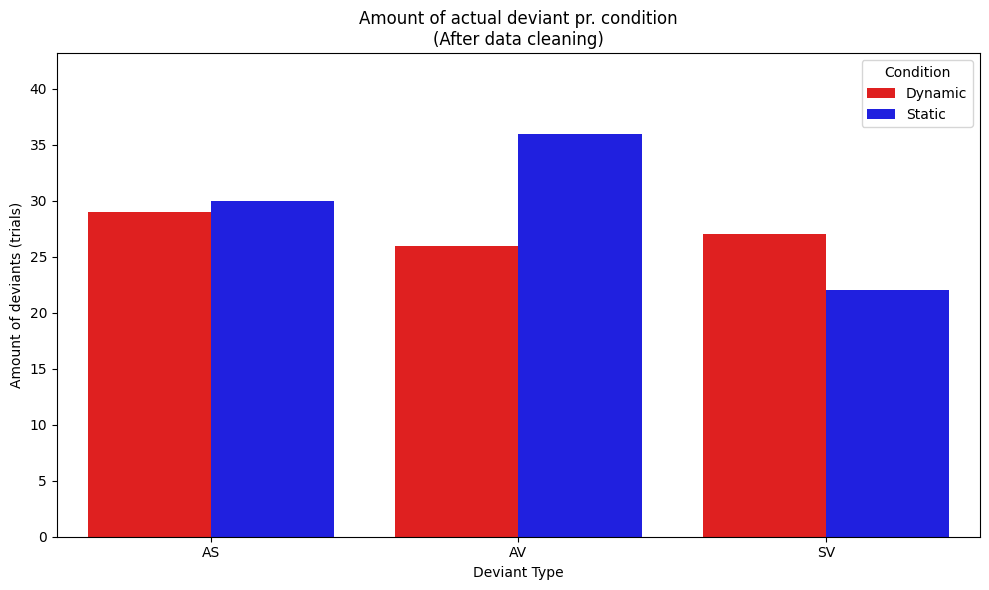

In [7]:
# ==========================================
# 8. TJEK ANTAL DEVIANTS (STATISK VS DYNAMISK)
# ==========================================
print("\nBeregner antal faktiske afvigere i dataen for alle betingelser...")

# Træk den underliggende pandas DataFrame ud fra vores rensede epochs
df_main = epochs_correct.metadata

# Filtrer, så vi KUN kigger på trials, der faktisk var deviants
df_deviants = df_main[df_main['stimulus_state'] == 'deviant']

# Tæl hvor mange der er af hver kombination (block_type x deviant_type)
counts = df_deviants.groupby(['block_type', 'deviant_type']).size().reset_index(name='Antal')

# Print de rå tal i konsollen (Rigtig godt til metodeafsnittet!)
print("\n--- FAKTISK ANTAL DEVIANTS I DATAEN ---")
print(counts.to_string(index=False))

# Lav et flot grupperet bar-plot
plt.figure(figsize=(10, 6))

# Brug 'hue' til at farvekode Statisk/Dynamisk og 'x' til at dele op i AV, SV, AS
sns.barplot(
    data=counts,
    x='deviant_type',
    y='Antal',
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'}
)

plt.title('Amount of actual deviant pr. condition\n(After data cleaning)')
plt.ylabel('Amount of deviants (trials)')
plt.xlabel('Deviant Type')

# Sæt y-aksen til at starte ved 0 og give lidt luft i toppen
plt.ylim(0, max(counts['Antal']) * 1.2)

# Gør 'legend' (signaturforklaringen) pænere
plt.legend(title='Condition', loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# 9. MARKOV KÆDER: HAZARD RATE PÅ P300
# ==========================================
import copy

# 1. Frasorter fejl-trials først! (Guldstandard)
epochs_correct = epochs_main["correct == True"]

# 2. Hent metadataen for at tilføje vores tæller
m = epochs_correct.metadata.copy()

# 3. Kør igennem alle trials og tæl hvor mange standarder, der har været i træk
run_lengths = []
current_run = 0

for state in m['stimulus_state']:
    if state == 'standard':
        current_run += 1
        run_lengths.append(current_run)
    else: # Hvis det er en deviant
        # Gem hvor mange standarder der kom LIGE FØR denne deviant
        run_lengths.append(current_run)
        current_run = 0 # Nulstil tælleren

# Tilføj den nye kolonne til vores metadata
m['run_length'] = run_lengths
epochs_correct.metadata = m

Replacing existing metadata with 11 columns



Beregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...


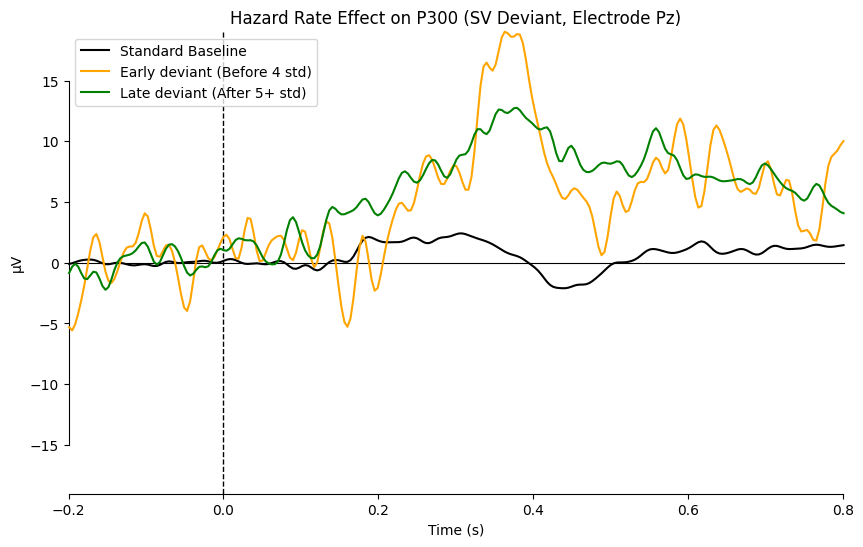

In [27]:
# ==========================================
# PLOT: TIDLIG VS SEN AFVIGER (Kun Dynamiske Blokke)
# ==========================================
print("\nBeregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...")

# Vi kigger kun på 'AV' (Multimodal) i de Dynamiske blokke, da det ofte giver det klareste P300
# Du kan ændre 'AV' til 'SV' eller 'AS'
valgt_afviger = 'SV'

# "Tidlige" afvigere: Kom efter kun 3 eller 4 standarder (Høj surprisal / stor overraskelse)
cond_early = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length < 4"].average()

# "Sene" afvigere: Kom efter 6 eller flere standarder (Lav surprisal / forventet)
cond_late = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length >= 6"].average()

# Den sorte baseline til sammenligning
cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

evokeds_hazard = {
    'Standard Baseline': cond_standard,
    'Early deviant (Before 4 std)': cond_early,
    'Late deviant (After 5+ std)': cond_late
}

colors = {
    'Standard Baseline': 'black',
    'Early deviant (Before 4 std)': 'orange',
    'Late deviant (After 5+ std)': 'green'
}

# Plot Pz for P300
fig, ax = plt.subplots(figsize=(10, 6))

mne.viz.plot_compare_evokeds(
    evokeds_hazard,
    picks=['Pz'],
    colors=colors,
    axes=ax,
    title=f'Hazard Rate Effect on P300 ({valgt_afviger} Deviant, Electrode Pz)',
    show_sensors=False
)

ax.axvspan(0.300, 0.500, color='yellow', alpha=0.2, label='P300 Vindue')
ax.legend(loc='lower left')
plt.show()



Genererer Topografiske kort...


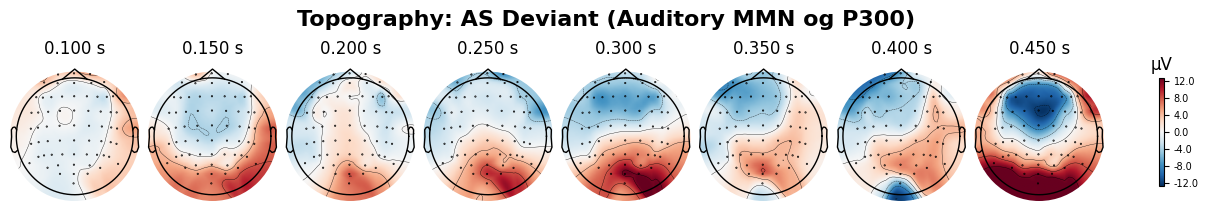

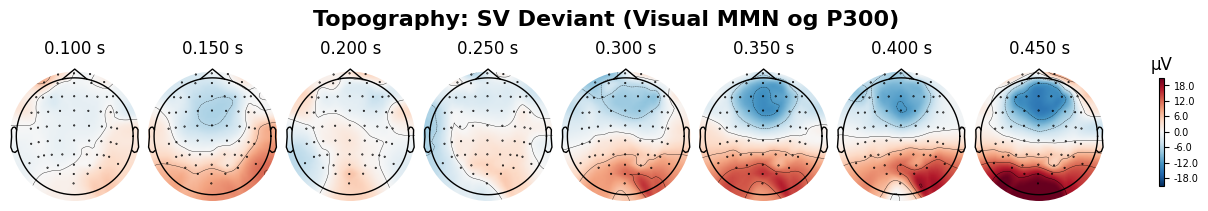

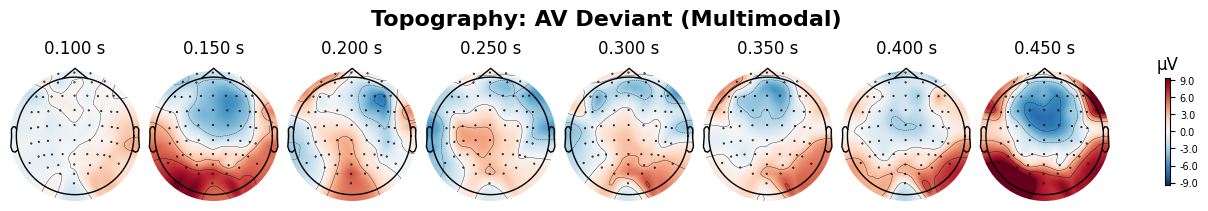

In [10]:
# ==========================================
# 10. TOPOGRAFISKE KORT (TOPOPLOTS)
# ==========================================
print("\nGenererer Topografiske kort...")

try:
    epochs_correct.set_montage('standard_1020')
except ValueError as e:
    print("Bemærk: Kanaler hedder nok noget lokalt (BioSemi), de mangler montage.")

evoked_as = epochs_correct["deviant_type == 'AS' and stimulus_state == 'deviant'"].average()
evoked_sv = epochs_correct["deviant_type == 'SV' and stimulus_state == 'deviant'"].average()
evoked_av = epochs_correct["deviant_type == 'AV' and stimulus_state == 'deviant'"].average()

times_to_plot = [0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400, 0.450]

# --- Plot AS ---
# Vi fanger 'fig' (figuren) som funktionen returnerer
fig_as = evoked_as.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
# Sæt den overordnede titel på selve figuren
fig_as.suptitle("Topography: AS Deviant (Auditory MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot SV ---
fig_sv = evoked_sv.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_sv.suptitle("Topography: SV Deviant (Visual MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot AV ---
fig_av = evoked_av.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_av.suptitle("Topography: AV Deviant (Multimodal)", fontsize=16, fontweight='bold')

# Vis dem alle sammen på én gang
plt.show()


Genererer 3D Entropi Landskab for P300...


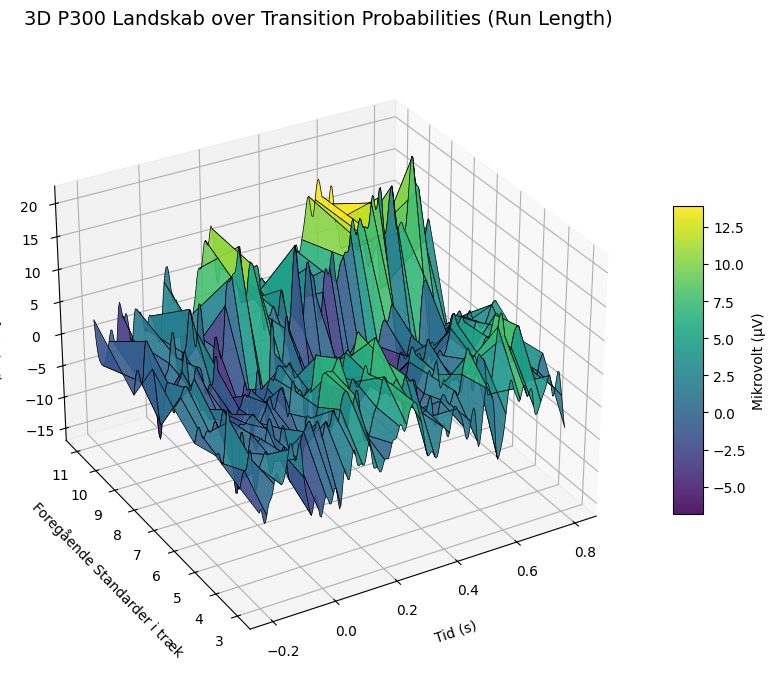

In [11]:
# ==========================================
# 11. 3D ENTOPI / SURPRISAL PLOT (P300)
# ==========================================
print("\nGenererer 3D Entropi Landskab for P300...")

epochs_dyn_av = epochs_correct["block_type == 'Dynamic' and deviant_type == 'AV' and stimulus_state == 'deviant'"]
ch_idx = epochs_correct.ch_names.index('Pz')
times = epochs_correct.times

# Saml de unikke 'run lengths' (vores entropi akse)
unique_runs = np.sort(epochs_dyn_av.metadata['run_length'].unique())

# Vi bygger en Z-matrix der skal holde alle mikrovolt-værdierne
Z_data = []
valid_runs = []

for run_len in unique_runs:
    data_for_run = epochs_dyn_av[f"run_length == {run_len}"].get_data(picks=ch_idx).squeeze()

    # Sikkerhedstjek: Spring over hvis der ikke er noget data
    if data_for_run.size == 0:
        continue

    if data_for_run.ndim == 1:
        mean_erp = data_for_run * 1e6
    else:
        mean_erp = data_for_run.mean(axis=0) * 1e6

    Z_data.append(mean_erp)
    valid_runs.append(run_len)

# Konverter til Numpy arrays
Z = np.array(Z_data)

# Skab et 2D gitter (Meshgrid) for X (Tid) og Y (Run Length)
X, Y = np.meshgrid(times, valid_runs)

# Sæt 3D figuren op
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot LANDSKABET (plot_surface)
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.5, alpha=0.9)

ax.set_title("3D P300 Landskab over Transition Probabilities (Run Length)", pad=20, fontsize=14)
ax.set_xlabel("Tid (s)", labelpad=10)
ax.set_ylabel("Foregående Standarder i træk", labelpad=10)
ax.set_zlabel("Amplitude på Pz (µV)", labelpad=10)

# Tilføj en farveskala (colorbar) til højre for plottet
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Mikrovolt (µV)')

# Roter kameraet lidt for at give den bedste vinkel
ax.view_init(elev=30, azim=-120)

plt.show()


Beregner Difference Waves (Det rene overraskelses-signal)...

Genererer Difference Waves for Auditory Deviant...


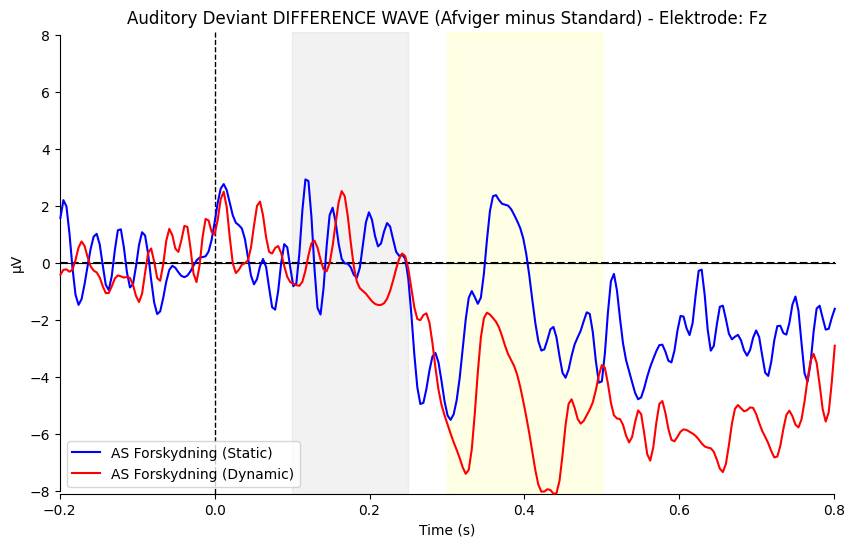

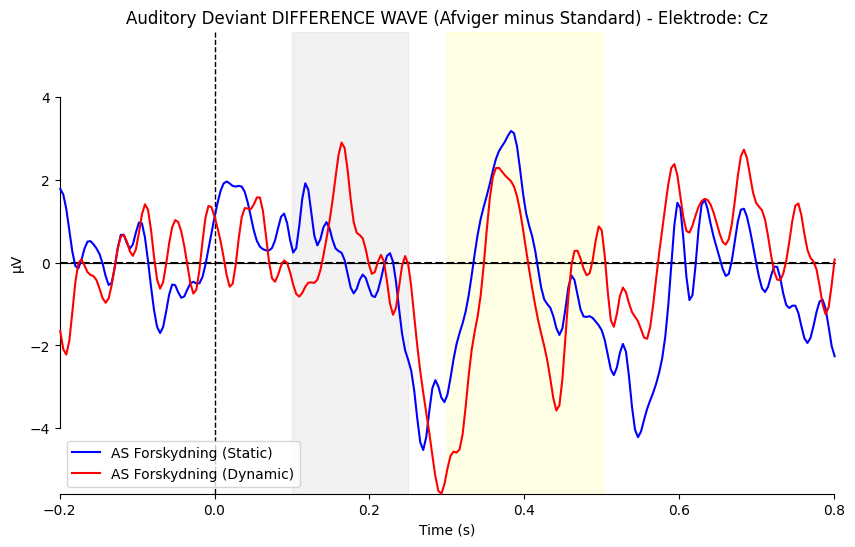


Genererer Difference Waves for Visual Deviant...


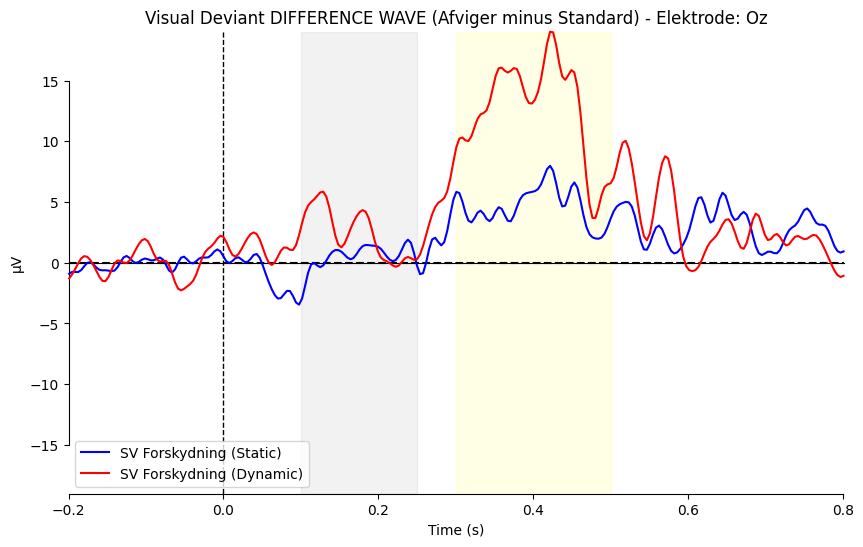

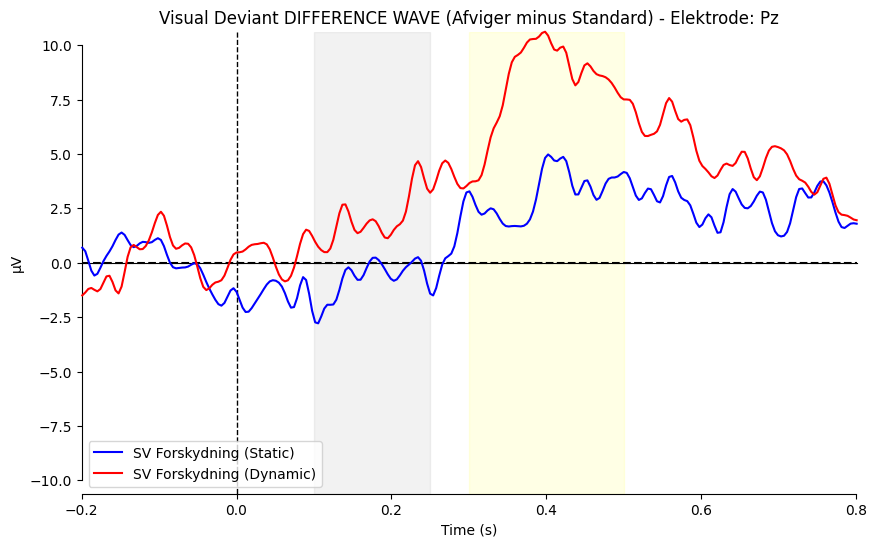


Genererer Difference Waves for Multimodal Deviant...


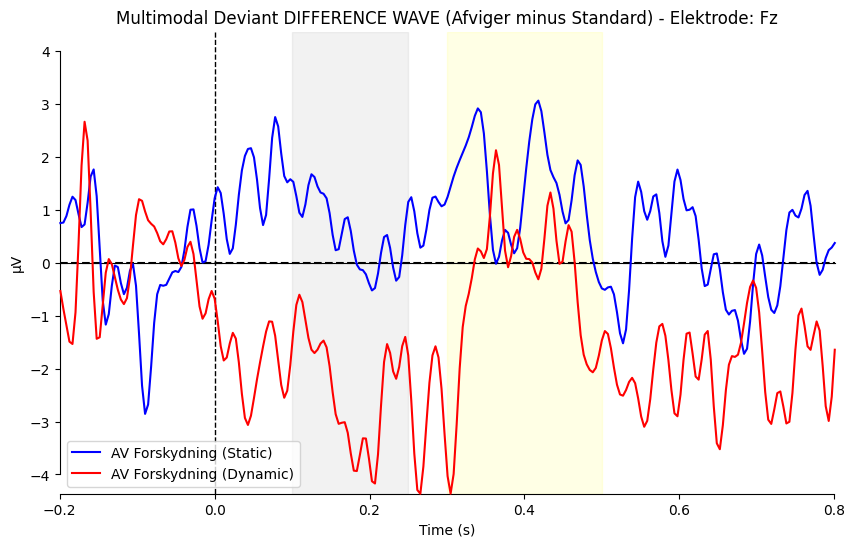

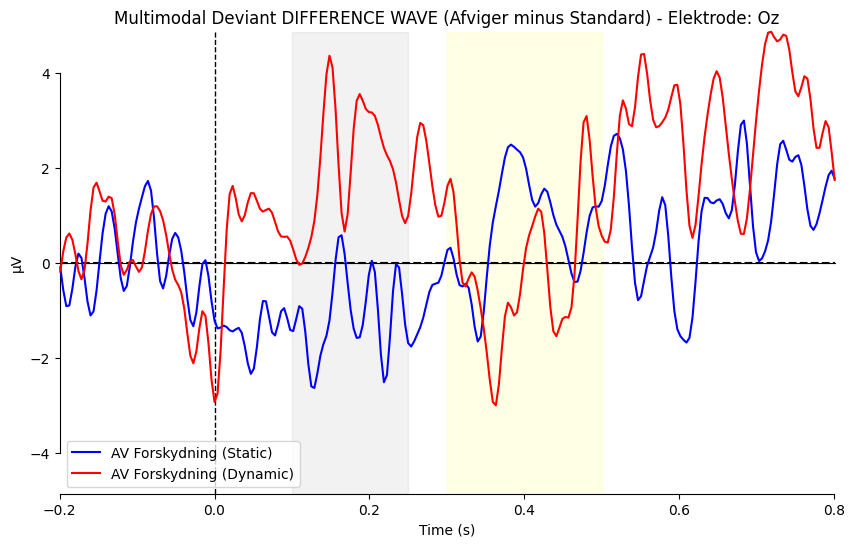

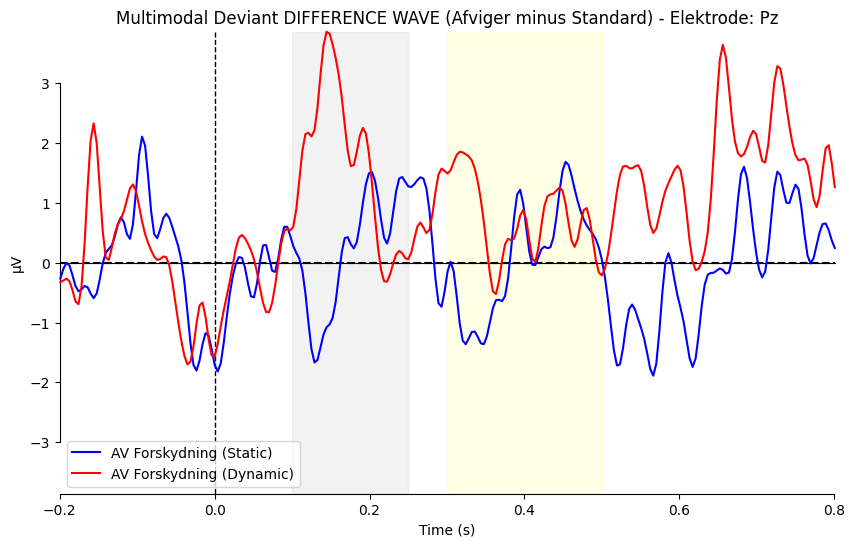

In [12]:
# ==========================================
# 12. DIFFERENCE WAVES (AFVIGER MINUS STANDARD)
# ==========================================
print("\nBeregner Difference Waves (Det rene overraskelses-signal)...")

# Vi skal bruge standarden til at trække fra alle andre
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# Vi genbruger din opsætning for elektroderne
deviant_configs = {
    'AS': {'name': 'Auditory Deviant', 'channels': ['Fz', 'Cz']},
    'SV': {'name': 'Visual Deviant', 'channels': ['Oz', 'Pz']},
    'AV': {'name': 'Multimodal Deviant', 'channels': ['Fz', 'Oz', 'Pz']}
}

for dev_type, config in deviant_configs.items():
    print(f"\nGenererer Difference Waves for {config['name']}...")

    # Hent de rene afvigere
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # BEREGN FORSKELLEN: MNE trækker værdien for standard (vægt -1) fra afvigeren (vægt 1)
    diff_stat = mne.combine_evoked([evoked_stat, evoked_std], weights=[1, -1])
    diff_dyn = mne.combine_evoked([evoked_dyn, evoked_std], weights=[1, -1])

    # Saml dem til plottet
    diff_dict = {
        f'{dev_type} Forskydning (Static)': diff_stat,
        f'{dev_type} Forskydning (Dynamic)': diff_dyn
    }

    colors = {
        f'{dev_type} Forskydning (Static)': 'blue',
        f'{dev_type} Forskydning (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            # Tegn en vandret sort, stiplet linje ved NUL (0 mikrovolt)
            # På en difference wave betyder 0, at hjernen reagerede PRÆCIS ens på standard og afviger!
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)

            mne.viz.plot_compare_evokeds(
                diff_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} DIFFERENCE WAVE (Afviger minus Standard) - Elektrode: {ch}",
                show_sensors=False,
                show=False
            )

            # Tegn zonerne i baggrunden
            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, zorder=0)

            # Ryd op i legend (Så den sorte "baseline" linje ikke står der to gange)
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...

--- Genererer ROI plots for Auditory Deviant (Sound) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


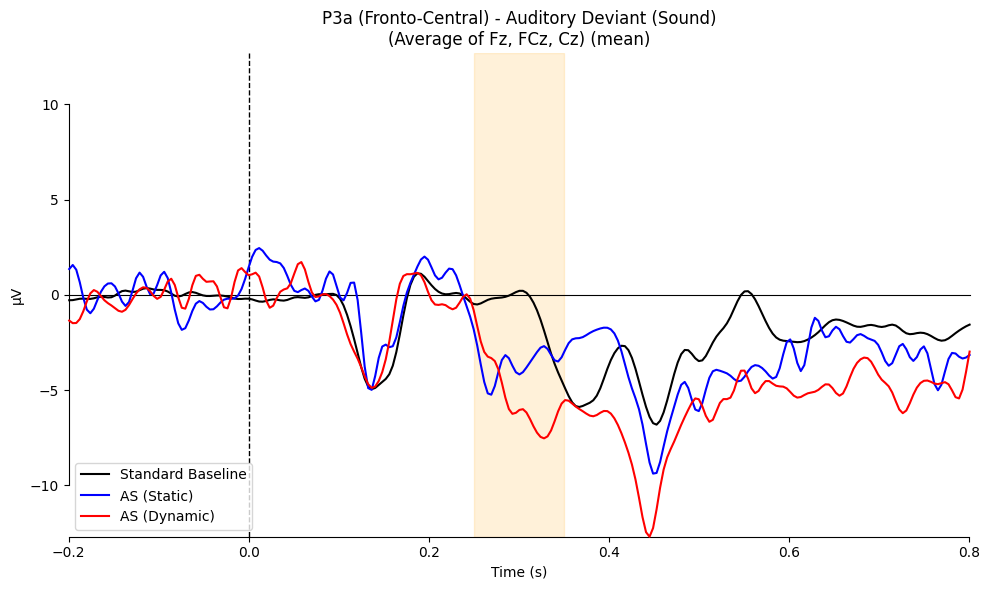

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


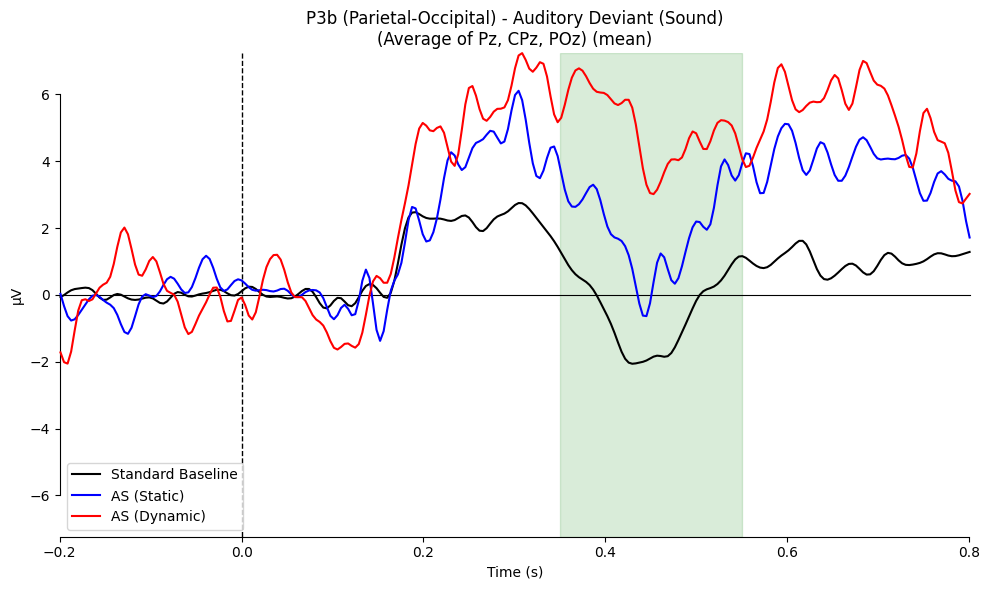


--- Genererer ROI plots for Visual Deviant (Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


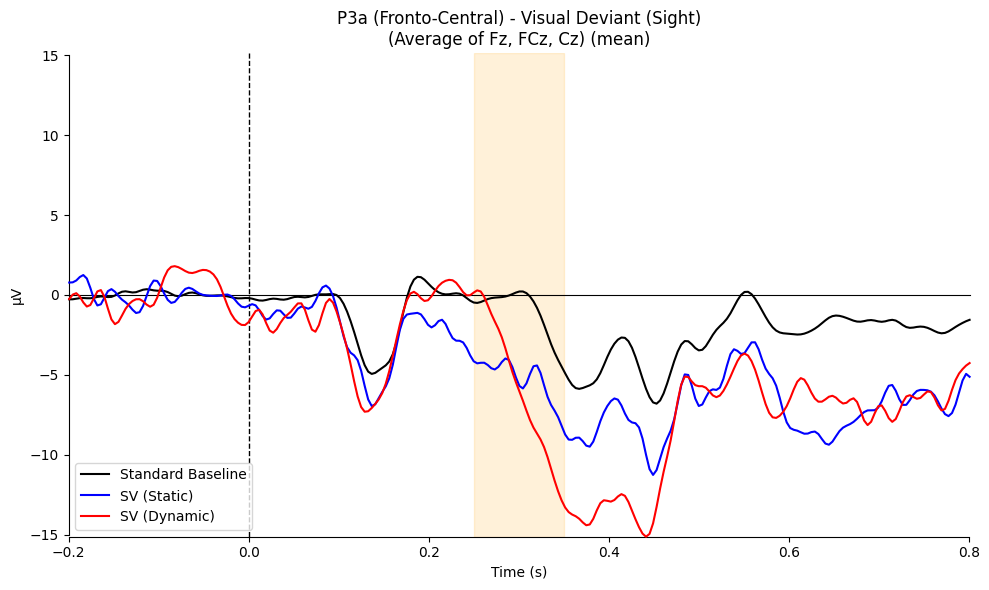

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


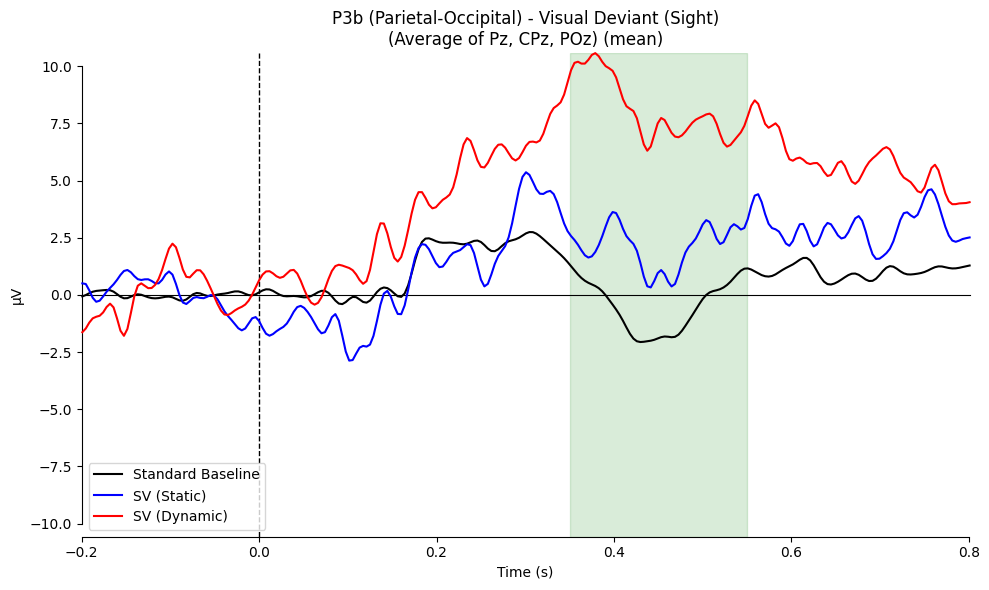


--- Genererer ROI plots for Multimodal Deviant (Sound+Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


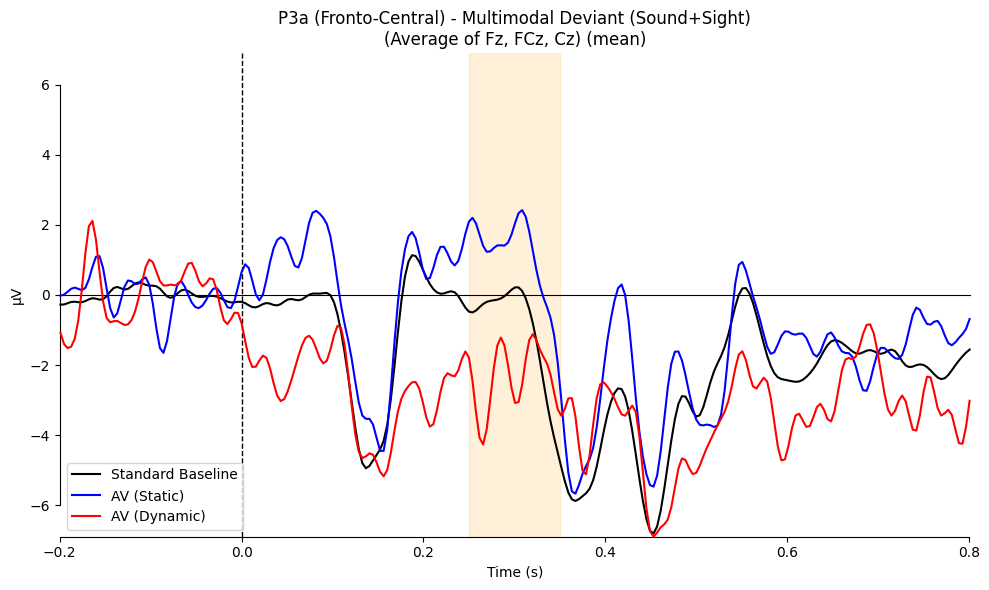

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


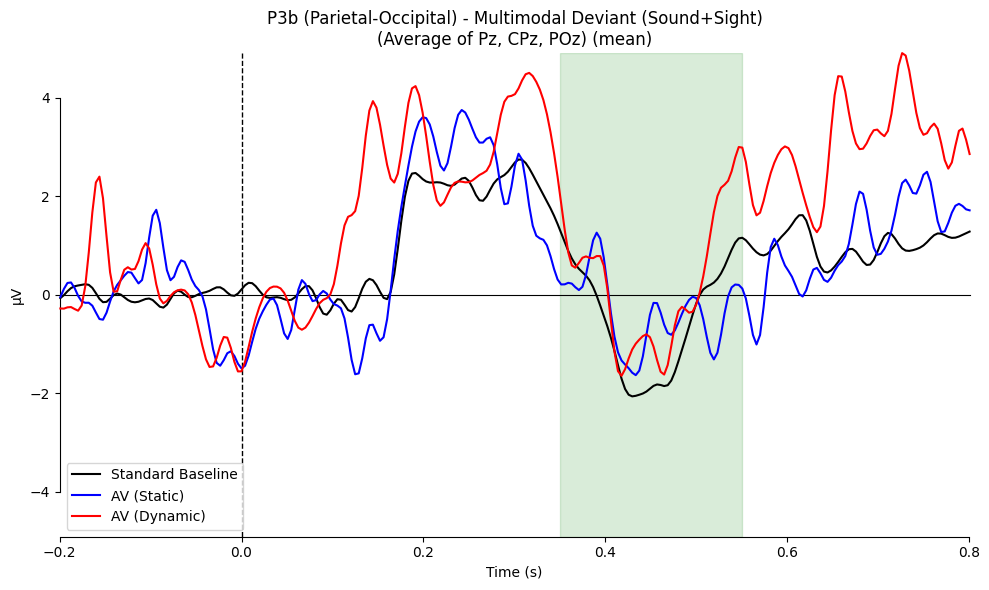

In [13]:
# ==========================================
# 13. P3a vs P3b (Region of Interest Analyse)
# ==========================================
import mne
import matplotlib.pyplot as plt

print("\nBeregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...")

# 1. Definer vores to Regions of Interest (ROI)
rois = {
    'P3a (Fronto-Central)': ['Fz', 'FCz', 'Cz'],
    'P3b (Parietal-Occipital)': ['Pz', 'CPz', 'POz']
}

# 2. Opsætning af de tre afvigertyper
deviant_names = {
    'AS': 'Auditory Deviant (Sound)',
    'SV': 'Visual Deviant (Sight)',
    'AV': 'Multimodal Deviant (Sound+Sight)'
}

# Hent standard-baselinen (den er ens for alle plots)
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# 3. Loop over hver afvigertype (AS, SV, AV)
for dev_type, dev_name in deviant_names.items():
    print(f"\n--- Genererer ROI plots for {dev_name} ---")
    
    # Hent Statisk og Dynamisk for netop denne afviger
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # Saml dem i en ordbog
    evokeds_dict = {
        'Standard Baseline': evoked_std,
        f'{dev_type} (Static)': evoked_stat,
        f'{dev_type} (Dynamic)': evoked_dyn
    }

    colors = {
        'Standard Baseline': 'black', 
        f'{dev_type} (Static)': 'blue', 
        f'{dev_type} (Dynamic)': 'red'
    }

    # 4. Plot for hver ROI for denne afviger
    for roi_name, channels in rois.items():
        # Sikkerhedstjek: Find kun de elektroder, der faktisk findes i jeres data
        valid_channels = [ch for ch in channels if ch in epochs_correct.ch_names]
        
        if not valid_channels:
            print(f"ADVARSEL: Fandt ingen af elektroderne til {roi_name} i dataen!")
            continue
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # combine='mean' tager gennemsnittet af kanalerne på tværs af ROI'en
        mne.viz.plot_compare_evokeds(
            evokeds_dict,
            picks=valid_channels,
            combine='mean', 
            colors=colors,
            axes=ax,
            title=f'{roi_name} - {dev_name}\n(Average of {", ".join(valid_channels)})',
            show_sensors=False,
            show=False 
        )
        
        # 5. Marker specifikke tidsvinduer baseret på komponenten
        if 'P3a' in roi_name:
            ax.axvspan(0.250, 0.350, color='orange', alpha=0.15, zorder=0)
        else:
            ax.axvspan(0.350, 0.550, color='green', alpha=0.15, zorder=0)
        
        # Ryd op i signaturforklaringen (legend)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='lower left')
        
        plt.tight_layout()
        plt.show()

C:\Users\lundb\AppData\Local\Temp\ipykernel_17404\1803139276.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  block_stats = df_main.groupby(['block_num', 'block_type', 'deviant_type']).apply(


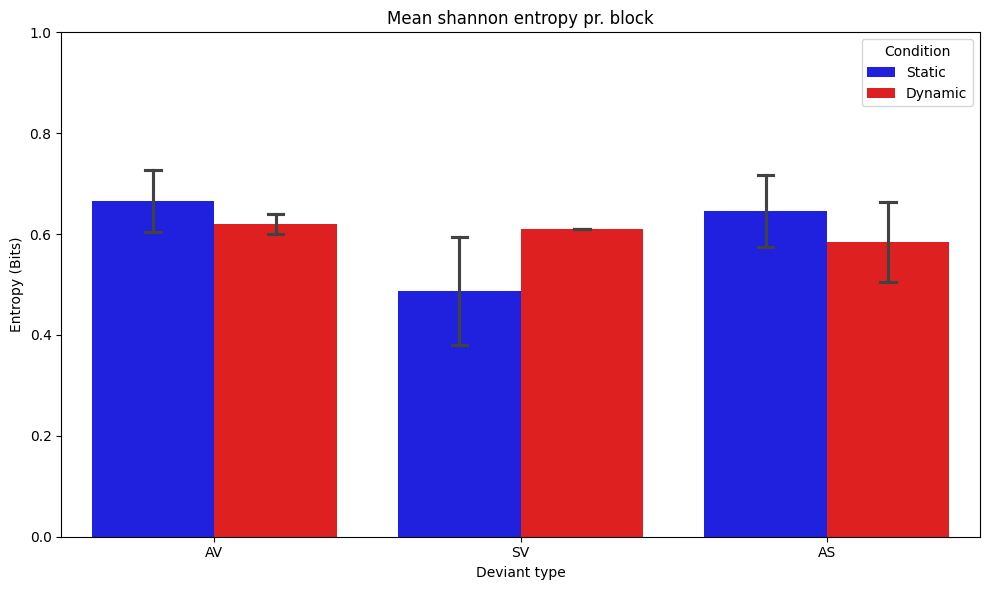

In [15]:
# Gennemsnitlig entropi på tværs af deviants, blokke og konditioner

df_main = df[~df['block_type'].str.contains('Training')].copy()

def shannon_entropy(p):
    if p <= 0 or p >= 1: # Hvis 0% eller 100% sandsynlighed er der 0 entropi (total forudsigelighed)
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Find den faktiske procentdel af deviants pr. blok
block_stats = df_main.groupby(['block_num', 'block_type', 'deviant_type']).apply(
    lambda x: (x['stimulus_state'] == 'deviant').mean()
).reset_index(name='p_deviant')

# Omregn procentdelen til Shannon Entropi
block_stats['entropy'] = block_stats['p_deviant'].apply(shannon_entropy)

plt.figure(figsize=(10, 6))
# errorbar='sd' tegner standardafvigelsen som en lille sort streg over søjlerne
sns.barplot(
    data=block_stats, 
    x='deviant_type', 
    y='entropy', 
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'},
    errorbar='sd',
    capsize=0.1
)

plt.title('Mean shannon entropy pr. block')
plt.ylabel('Entropy (Bits)')
plt.xlabel('Deviant type')
plt.ylim(0, 1) # Entropi for binære valg går fra 0 til 1
plt.legend(title='Condition', loc='upper right')
plt.tight_layout()
plt.show()

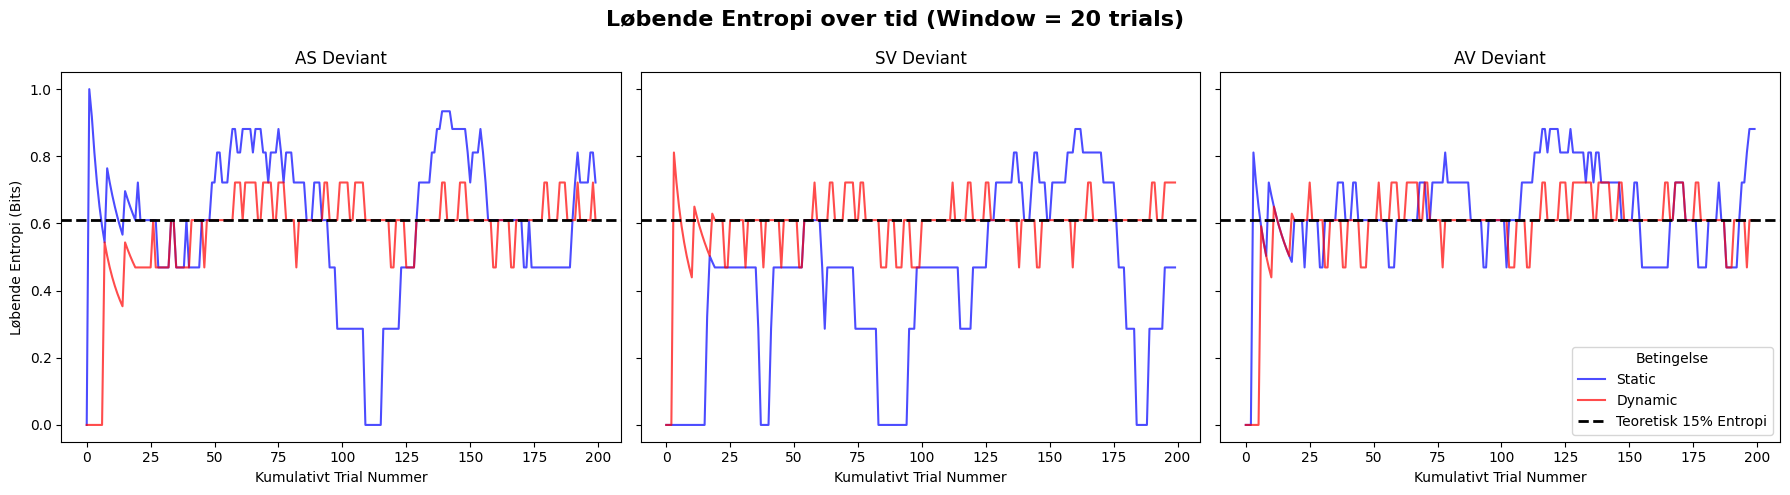

In [17]:
# Løbende entropi

window_size = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'Løbende Entropi over tid (Window = {window_size} trials)', fontsize=16, fontweight='bold')

deviant_types = ['AS', 'SV', 'AV']
colors = {'Static': 'blue', 'Dynamic': 'red'}

for i, dev_type in enumerate(deviant_types):
    ax = axes[i]
    
    for b_type in ['Static', 'Dynamic']:
        # Hent data for denne kombination (f.eks. AV Statisk)
        subset = df_main[(df_main['deviant_type'] == dev_type) & (df_main['block_type'] == b_type)].copy()
        
        # Sørg for at de ligger i den rækkefølge, de blev vist i forsøget
        subset = subset.sort_values(['block_num', 'trial_num'])
        
        # Lav en binær kolonne: 1 for deviant, 0 for standard
        subset['is_deviant'] = (subset['stimulus_state'] == 'deviant').astype(int)
        
        # Beregn den løbende sandsynlighed over de sidste 20 trials
        subset['rolling_p'] = subset['is_deviant'].rolling(window=window_size, min_periods=1).mean()
        
        # Beregn den løbende entropi
        subset['rolling_entropy'] = subset['rolling_p'].apply(shannon_entropy)
        
        # Plot resultatet
        ax.plot(range(len(subset)), subset['rolling_entropy'], label=b_type, color=colors[b_type], alpha=0.7, linewidth=1.5)
        
    ax.set_title(f'{dev_type} Deviant')
    ax.set_xlabel('Kumulativt Trial Nummer')
    if i == 0:
        ax.set_ylabel('Løbende Entropi (Bits)')
    ax.set_ylim(-0.05, 1.05)
    
    # En sort streg der viser den "Teoretiske" entropi for 15% (ca. 0.61 bits)
    theoretical_entropy = shannon_entropy(0.15)
    ax.axhline(theoretical_entropy, color='black', linestyle='--', linewidth=2, label='Teoretisk 15% Entropi')
    
    if i == 2:
        ax.legend(title='Betingelse')

plt.tight_layout()
plt.show()

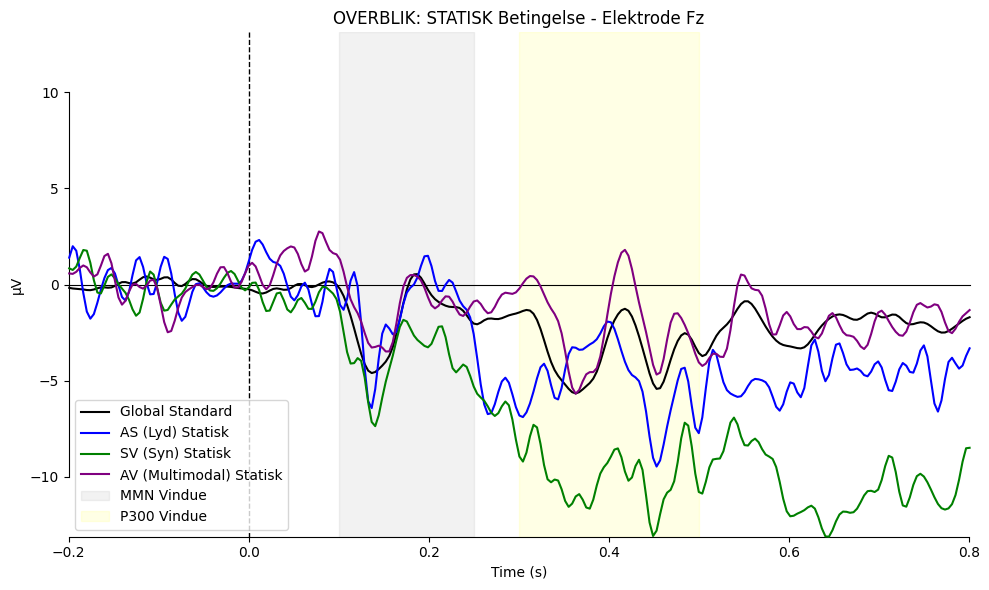

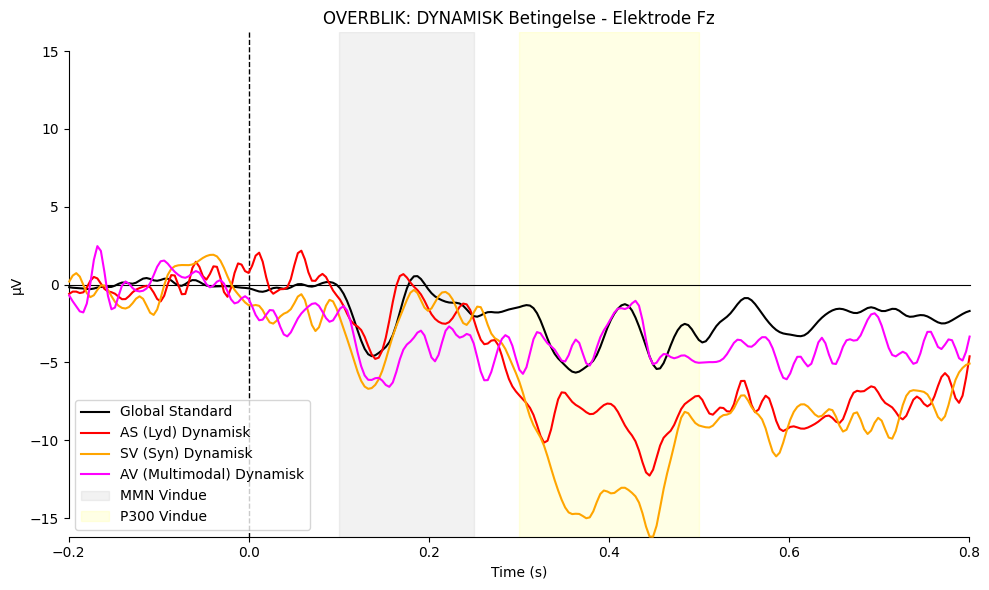

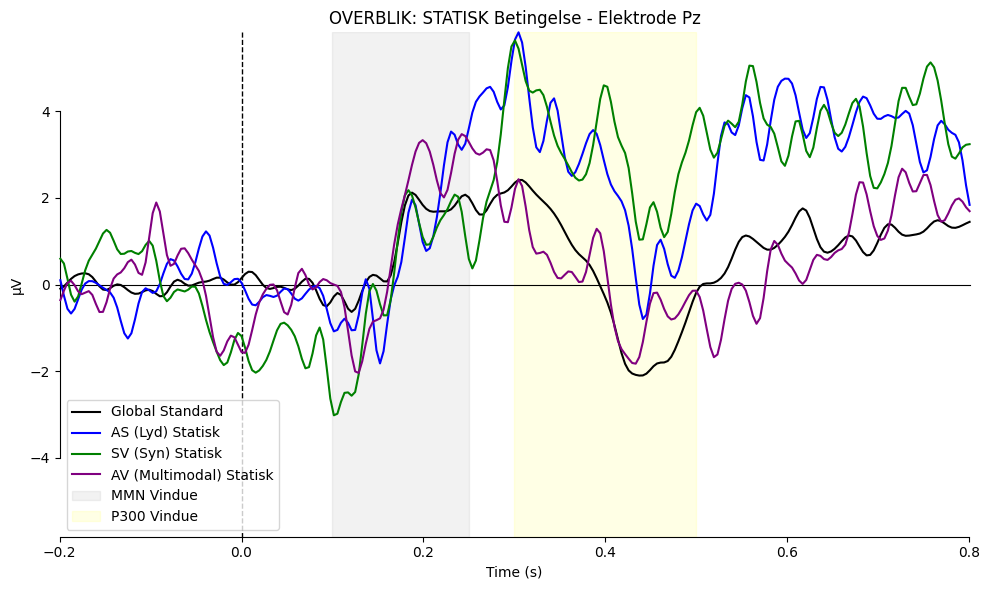

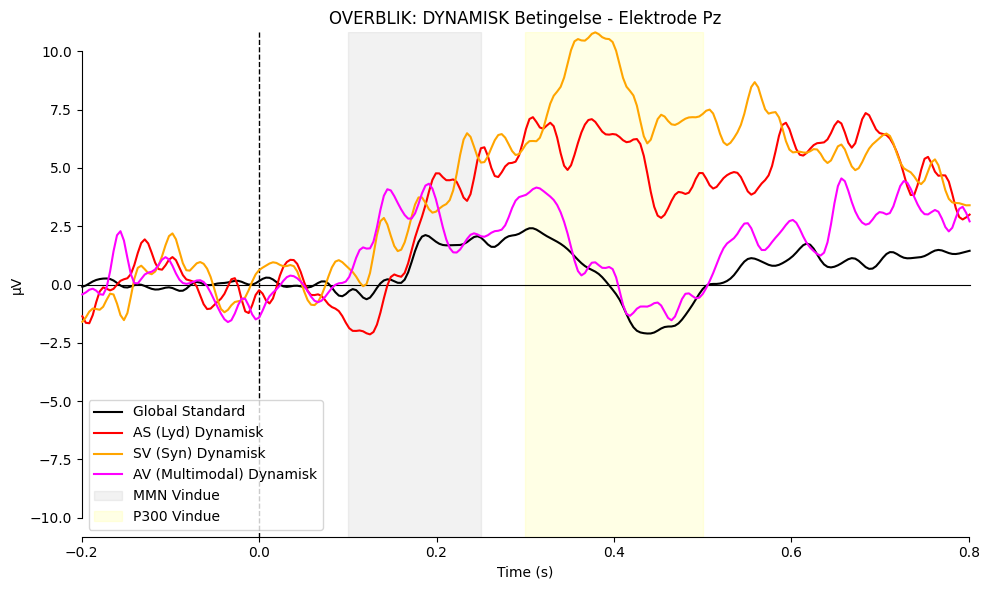

In [18]:
# 1. Skab den Globale Standard (Gennemsnit af ALLE standarder på tværs af alle blokke)
evoked_global_std = epochs_correct["stimulus_state == 'standard'"].average()

# 2. Hent gennemsnittet for alle de individuelle afvigere
evokeds = {
    'AS_stat': epochs_correct["block_type == 'Static' and deviant_type == 'AS' and stimulus_state == 'deviant'"].average(),
    'SV_stat': epochs_correct["block_type == 'Static' and deviant_type == 'SV' and stimulus_state == 'deviant'"].average(),
    'AV_stat': epochs_correct["block_type == 'Static' and deviant_type == 'AV' and stimulus_state == 'deviant'"].average(),
    
    'AS_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'AS' and stimulus_state == 'deviant'"].average(),
    'SV_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'SV' and stimulus_state == 'deviant'"].average(),
    'AV_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'AV' and stimulus_state == 'deviant'"].average()
}

# 3. Opsæt vores to store plots (Statisk og Dynamisk)
plot_configs = {
    'STATISK Betingelse': {
        'dict': {
            'Global Standard': evoked_global_std,
            'AS (Lyd) Statisk': evokeds['AS_stat'],
            'SV (Syn) Statisk': evokeds['SV_stat'],
            'AV (Multimodal) Statisk': evokeds['AV_stat']
        },
        'colors': {'Global Standard': 'black', 'AS (Lyd) Statisk': 'blue', 'SV (Syn) Statisk': 'green', 'AV (Multimodal) Statisk': 'purple'}
    },
    'DYNAMISK Betingelse': {
        'dict': {
            'Global Standard': evoked_global_std,
            'AS (Lyd) Dynamisk': evokeds['AS_dyn'],
            'SV (Syn) Dynamisk': evokeds['SV_dyn'],
            'AV (Multimodal) Dynamisk': evokeds['AV_dyn']
        },
        'colors': {'Global Standard': 'black', 'AS (Lyd) Dynamisk': 'red', 'SV (Syn) Dynamisk': 'orange', 'AV (Multimodal) Dynamisk': 'magenta'}
    }
}

# Vælg hvilke elektroder der er spændende at se dette overblik på
electrodes_to_plot = ['Fz', 'Pz']

for ch in electrodes_to_plot:
    if ch not in epochs_correct.ch_names:
        continue
        
    for condition_name, config in plot_configs.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        
        mne.viz.plot_compare_evokeds(
            config['dict'],
            picks=[ch],
            colors=config['colors'],
            axes=ax,
            title=f"OVERBLIK: {condition_name} - Elektrode {ch}",
            show_sensors=False,
            show=False
        )
        
        # Tegn zoner
        ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, label='MMN Vindue', zorder=0)
        ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, label='P300 Vindue', zorder=0)
        
        # Ryd op i legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='lower left')
        
        plt.tight_layout()
        plt.show()